# Does the phyllosphere community reassemble after rain?

The Shannon-diversity analysis in `bacteria_to_transcriptome_time_abundance_rain_correlation.ipynb`
showed that rain knocks genus-level diversity down and that diversity then climbs back over the
following days. Shannon is composition-blind, though: a community that re-fills from an entirely
different pool looks identical to one that snaps back to its pre-rain state.

This notebook asks the compositional question with **Bray-Curtis dissimilarity**. For each rain
event we take three timepoints — `pre` (last dry sampling before the rain), `post` (first sampling
after it, the disturbed community) and `recovered` (the next sampling, once diversity has climbed
back) — and ask whether `pre` and `recovered` are closer to each other than the disturbance itself
was.

The essential reference is the **within-timepoint distance**: eight plants harvested the same
morning are already very different from one another. Any between-timepoint signal only means
something measured against that floor.

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as st
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.spatial.distance import cdist, pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, permdisp
from skbio.stats.ordination import pcoa
from statsmodels.stats.multitest import multipletests

import meteostat

# Okabe-Ito, a published colourblind-safe qualitative palette. Hues are assigned to a
# fixed role below and never recycled between figures.
COLOR_WITHIN = "#6E6E6E"  # plant-to-plant baseline
COLOR_PRE_POST = "#0072B2"  # the disturbance itself
COLOR_PRE_REC = "#D55E00"  # the question: did it come back?
COLOR_POST_REC = "#009E73"  # the second half of the trajectory

DATA = "/Users/michael/Data/Luke_terrace_experiment/"


def style_axes(ax):
    """Match the figure styling used throughout the source notebook."""
    sns.despine(ax=ax)
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(2)
    ax.tick_params(axis="both", width=2, labelsize=10)
    return ax

## 1. Load the 16S data

The merge is against the **untrimmed** metadata, matching the source notebook: the RNA-quality
sample exclusions do not apply to DNA-based amplicon data.

In [2]:
metadata = pd.read_csv(
    DATA + "General_data/Plates_1_to_4_metadata_merged_luke.csv", index_col=0
)
metadata["Date and Time"] = pd.to_datetime(
    metadata["date"] + " " + metadata["time"], format="%m/%d/%y %H:%M"
)

microbiome_abundance = pd.read_csv(DATA + "Microbiome/lic2024_16S_rab.csv")
long_term_microbiome = microbiome_abundance.merge(
    metadata[["sampID", "Experiment Type"]], left_on="plantID", right_on="sampID"
)
long_term_microbiome = long_term_microbiome.loc[
    long_term_microbiome["Experiment Type"] == "Long Term"
]
long_term_microbiome.head()

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100,sampID,Experiment Type
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1,LIC063,Long Term
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5,LIC159,Long Term
4,LIC306,plant,t26,3/8/24,8:00,LIC_04,128,LIC306,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,57.2,LIC306,Long Term
5,LIC016,plant,t02,11/7/23,8:00,LIC_01,6,LIC016,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,54.4,LIC016,Long Term
9,LIC051,plant,t05,11/21/23,8:00,LIC_01,20,LIC051,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Rhizobiales_505101,Rhizobiaceae,Neorhizobium_500197,Neorhizobium soli,49.7,LIC051,Long Term


## 2. Sample x taxon relative-abundance matrices

`AbundR100` is a percentage, but it does **not** sum to 100 per sample (78.5-95.2 here) because the
source table is filtered to taxa at >=0.5% relative abundance. Bray-Curtis is sensitive to unequal
totals, so every sample vector is renormalised to sum to 1.

Pivoting with `fillna(0)` does the same job as the explicit zero-filling loop in the source
notebook, vectorised.

In [3]:
def build_relative_abundance_matrix(long_form, level):
    """Sample x taxon matrix of proportions at the requested taxonomic level."""
    summed = long_form.groupby(["Sample", level])["AbundR100"].sum()
    matrix = summed.unstack(level).fillna(0).sort_index()
    return matrix.div(matrix.sum(axis=1), axis=0)


genus_matrix = build_relative_abundance_matrix(long_term_microbiome, "Genus")
species_matrix = build_relative_abundance_matrix(long_term_microbiome, "Species")

timepoint_of_sample = (
    long_term_microbiome.groupby("Sample")["timepoint"].first().reindex(genus_matrix.index)
)
timepoints = sorted(timepoint_of_sample.unique())
timepoint_datetimes = (
    metadata.loc[metadata["Experiment Type"] == "Long Term", ["timepoint", "Date and Time"]]
    .drop_duplicates("timepoint")
    .set_index("timepoint")["Date and Time"]
    .sort_values()
)

assert np.allclose(genus_matrix.sum(axis=1), 1)
assert np.allclose(species_matrix.sum(axis=1), 1)
print("genus matrix   ", genus_matrix.shape)
print("species matrix ", species_matrix.shape)
print("samples per timepoint:", timepoint_of_sample.value_counts().sort_index().to_dict())

genus matrix    (222, 137)
species matrix  (222, 256)
samples per timepoint: {'t01': 8, 't02': 8, 't03': 8, 't04': 8, 't05': 8, 't06': 8, 't07': 8, 't08': 8, 't09': 8, 't10': 8, 't11': 8, 't12': 8, 't13': 7, 't14': 7, 't15': 8, 't16': 8, 't17': 8, 't18': 8, 't19': 8, 't20': 8, 't21': 8, 't22': 8, 't23': 8, 't24': 8, 't25': 8, 't26': 8, 't27': 8, 't28': 8}


## 3. Bray-Curtis distances and the within/between helpers

In [4]:
def bray_curtis_matrix(abundance_matrix):
    distances = squareform(pdist(abundance_matrix.values, metric="braycurtis"))
    return pd.DataFrame(distances, index=abundance_matrix.index, columns=abundance_matrix.index)


genus_bc = bray_curtis_matrix(genus_matrix)
species_bc = bray_curtis_matrix(species_matrix)

samples_at = {t: timepoint_of_sample.index[timepoint_of_sample == t] for t in timepoints}


def within_distances(bc, timepoint):
    """All plant-vs-plant distances inside one timepoint (28 pairs when n = 8)."""
    s = samples_at[timepoint]
    return squareform(bc.loc[s, s].values, checks=False)


def between_distances(bc, timepoint_a, timepoint_b):
    """All cross-timepoint distances (64 pairs when both n = 8)."""
    return bc.loc[samples_at[timepoint_a], samples_at[timepoint_b]].values.ravel()


assert np.allclose(genus_bc.values, genus_bc.values.T)
assert np.allclose(np.diag(genus_bc.values), 0)

all_within = np.concatenate([within_distances(genus_bc, t) for t in timepoints])
all_between = np.concatenate(
    [
        between_distances(genus_bc, a, b)
        for i, a in enumerate(timepoints)
        for b in timepoints[i + 1 :]
    ]
)
print(f"mean within-timepoint  Bray-Curtis: {all_within.mean():.3f}")
print(f"mean between-timepoint Bray-Curtis: {all_between.mean():.3f}")
print(
    "within-timepoint means range "
    f"{min(within_distances(genus_bc, t).mean() for t in timepoints):.3f}"
    f" - {max(within_distances(genus_bc, t).mean() for t in timepoints):.3f}"
)

mean within-timepoint  Bray-Curtis: 0.466
mean between-timepoint Bray-Curtis: 0.507
within-timepoint means range 0.298 - 0.572


Two plants picked on the same morning differ by a Bray-Curtis distance of ~0.47, and two plants from
*different* timepoints anywhere in the six-month experiment differ by ~0.51. Almost all of the
compositional variation in this dataset is between neighbouring plants, not between dates. That sets
the scale for everything below: a rain effect has to clear a very noisy floor.

## 4. Rain events

Hourly precipitation from the same Meteostat point the source notebook uses. For every sampling
timepoint we record rain in the previous 24h and 48h, plus everything that fell since the previous
sampling.

In [5]:
start_time = dt.datetime(2023, 10, 1)
end_time = dt.datetime(2024, 4, 30)
luke_apt_point = meteostat.Point(40.73005, -73.99450)
luke_hourly_data = meteostat.Hourly(luke_apt_point, start_time, end_time).fetch()
precipitation = luke_hourly_data["prcp"].fillna(0).sort_index()


def rolling_rain_at(window, when):
    """Rain accumulated over `window` ending at sampling time `when`."""
    rolled = precipitation.rolling(window).sum()
    return rolled.reindex(rolled.index.union([when])).sort_index().ffill().loc[when]


rain_context = pd.DataFrame(
    {
        "datetime": timepoint_datetimes,
        "rain_24h": [rolling_rain_at("24h", t) for t in timepoint_datetimes],
        "rain_48h": [rolling_rain_at("48h", t) for t in timepoint_datetimes],
        "rain_since_prev": [np.nan]
        + [
            precipitation.loc[a:b].sum()
            for a, b in zip(timepoint_datetimes[:-1], timepoint_datetimes[1:])
        ],
        "days_since_prev": [np.nan]
        + [(b - a).days for a, b in zip(timepoint_datetimes[:-1], timepoint_datetimes[1:])],
    }
).round(2)
rain_context

,datetime,rain_24h,rain_48h,rain_since_prev,days_since_prev
timepoint,,,,,
t01,2023-11-01 08:00:00,0.7,0.8,NaN,NaN
t02,2023-11-07 08:00:00,0.0,0.0,1.7,6.0
t03,2023-11-14 08:00:00,0.4,0.4,12.9,7.0
t04,2023-11-17 08:00:00,0.0,0.0,0.0,3.0
t05,2023-11-21 08:00:00,0.0,0.0,1.0,4.0
t06,2023-11-28 08:00:00,0.0,8.1,42.6,7.0
t07,2023-12-01 08:00:00,0.0,0.0,0.0,3.0
t08,2023-12-05 08:00:00,0.0,18.5,23.5,4.0
t09,2023-12-08 08:00:00,0.0,0.0,0.0,3.0


### The five events

Chosen from the table above so that each has a dry `pre` timepoint (no rain in the previous 48h), a
substantial soaking between `pre` and `post`, and a `recovered` timepoint that is itself dry. They
are hard-coded rather than rule-generated because rain is frequent enough here that a naive
threshold produces overlapping, uninterpretable events.

Caveat carried forward: the January event spans a 10-day `pre`->`post` gap and follows a very wet
21-day sampling break, so seasonal drift is a larger confound there than in the others.

In [6]:
EVENTS = [
    {"name": "Nov 21-28", "pre": "t05", "post": "t06", "recovered": "t07"},
    {"name": "Dec 1-5", "pre": "t07", "post": "t08", "recovered": "t09"},
    {"name": "Dec 8-12", "pre": "t09", "post": "t10", "recovered": "t11"},
    {"name": "Jan 5-15", "pre": "t12", "post": "t13", "recovered": "t14"},
    {"name": "Mar 5-8", "pre": "t25", "post": "t26", "recovered": "t27"},
]

event_context = pd.DataFrame(
    [
        {
            "event": ev["name"],
            "pre": ev["pre"],
            "post": ev["post"],
            "recovered": ev["recovered"],
            "rain_before_pre_48h": rain_context.loc[ev["pre"], "rain_48h"],
            "rain_pre_to_post": rain_context.loc[ev["post"], "rain_since_prev"],
            "days_pre_to_post": rain_context.loc[ev["post"], "days_since_prev"],
            "rain_post_to_rec": rain_context.loc[ev["recovered"], "rain_since_prev"],
            "days_post_to_rec": rain_context.loc[ev["recovered"], "days_since_prev"],
        }
        for ev in EVENTS
    ]
).set_index("event")
event_context

,pre,post,recovered,rain_before_pre_48h,rain_pre_to_post,days_pre_to_post,rain_post_to_rec,days_post_to_rec
event,,,,,,,,
Nov 21-28,t05,t06,t07,0.0,42.6,7.0,0.0,3.0
Dec 1-5,t07,t08,t09,0.0,23.5,4.0,0.0,3.0
Dec 8-12,t09,t10,t11,0.0,45.0,4.0,0.0,3.0
Jan 5-15,t12,t13,t14,0.0,122.3,10.0,12.1,8.0
Mar 5-8,t25,t26,t27,0.0,54.2,3.0,24.6,4.0


## 5. Distances within and between the event timepoints

`excess` is the between-timepoint distance with the plant-to-plant floor subtracted:

```
excess(a, b) = mean_between(a, b) - 0.5 * (mean_within(a) + mean_within(b))
```

An excess near zero means two timepoints are no more different from each other than two plants
harvested on the same morning.

In [7]:
def excess_distance(bc, timepoint_a, timepoint_b):
    within_floor = 0.5 * (
        within_distances(bc, timepoint_a).mean() + within_distances(bc, timepoint_b).mean()
    )
    return between_distances(bc, timepoint_a, timepoint_b).mean() - within_floor


def event_summary(bc):
    rows = []
    for ev in EVENTS:
        pre, post, rec = ev["pre"], ev["post"], ev["recovered"]
        rows.append(
            {
                "event": ev["name"],
                "within pre": within_distances(bc, pre).mean(),
                "within post": within_distances(bc, post).mean(),
                "within recovered": within_distances(bc, rec).mean(),
                "pre vs post": between_distances(bc, pre, post).mean(),
                "post vs recovered": between_distances(bc, post, rec).mean(),
                "pre vs recovered": between_distances(bc, pre, rec).mean(),
                "excess pre-post": excess_distance(bc, pre, post),
                "excess post-recovered": excess_distance(bc, post, rec),
                "excess pre-recovered": excess_distance(bc, pre, rec),
            }
        )
    return pd.DataFrame(rows).set_index("event")


genus_event_summary = event_summary(genus_bc)
genus_event_summary.round(3)

,within pre,within post,within recovered,pre vs post,post vs recovered,pre vs recovered,excess pre-post,excess post-recovered,excess pre-recovered
event,,,,,,,,,
Nov 21-28,0.572,0.499,0.558,0.552,0.533,0.597,0.016,0.004,0.032
Dec 1-5,0.558,0.489,0.520,0.531,0.531,0.561,0.007,0.026,0.022
Dec 8-12,0.520,0.563,0.532,0.545,0.541,0.564,0.004,-0.007,0.038
Jan 5-15,0.571,0.432,0.552,0.494,0.483,0.561,-0.007,-0.009,-0.001
Mar 5-8,0.385,0.430,0.340,0.402,0.378,0.375,-0.005,-0.007,0.013


In [8]:
CATEGORIES = [
    ("within pre", "within", COLOR_WITHIN),
    ("within post", "within", COLOR_WITHIN),
    ("within recovered", "within", COLOR_WITHIN),
    ("pre vs post", "between", COLOR_PRE_POST),
    ("post vs recovered", "between", COLOR_POST_REC),
    ("pre vs recovered", "between", COLOR_PRE_REC),
]


def pooled_distance_frame(bc):
    """Every individual pairwise distance from the five events, tagged by category."""
    rows = []
    for ev in EVENTS:
        pre, post, rec = ev["pre"], ev["post"], ev["recovered"]
        for category, values in [
            ("within pre", within_distances(bc, pre)),
            ("within post", within_distances(bc, post)),
            ("within recovered", within_distances(bc, rec)),
            ("pre vs post", between_distances(bc, pre, post)),
            ("post vs recovered", between_distances(bc, post, rec)),
            ("pre vs recovered", between_distances(bc, pre, rec)),
        ]:
            rows.append(
                pd.DataFrame(
                    {"event": ev["name"], "category": category, "bray_curtis": values}
                )
            )
    return pd.concat(rows, ignore_index=True)


pooled_distances = pooled_distance_frame(genus_bc)
pooled_distances.groupby("category")["bray_curtis"].agg(["mean", "std", "count"]).reindex(
    [c[0] for c in CATEGORIES]
).round(3)

,mean,std,count
category,,,
within pre,0.521,0.143,140
within post,0.486,0.121,133
within recovered,0.498,0.142,133
pre vs post,0.505,0.133,312
post vs recovered,0.494,0.133,305
pre vs recovered,0.531,0.146,312


## Figure 1 - the comparison

Left: every individual pairwise distance, pooled over the five events, with each event's mean drawn
on top so a single event driving the result would be visible. Right: the same contrasts with the
within-timepoint floor subtracted.

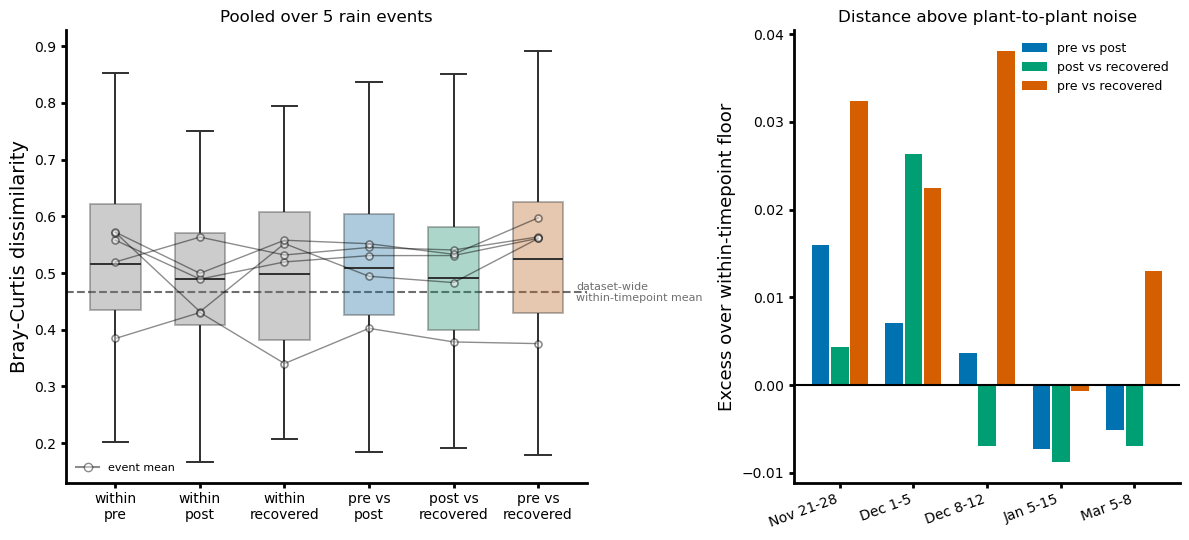

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), width_ratios=[1.35, 1])
fig.patch.set_facecolor("white")

# --- left panel: pooled distributions
ax = axes[0]
order = [c[0] for c in CATEGORIES]
palette = {c[0]: c[2] for c in CATEGORIES}
sns.boxplot(
    data=pooled_distances,
    x="category",
    y="bray_curtis",
    order=order,
    hue="category",
    palette=palette,
    legend=False,
    fliersize=0,
    width=0.6,
    linewidth=1.4,
    boxprops={"alpha": 0.35},
    ax=ax,
)
event_means = (
    pooled_distances.groupby(["event", "category"])["bray_curtis"].mean().reset_index()
)
for event_name, block in event_means.groupby("event"):
    block = block.set_index("category").reindex(order).reset_index()
    ax.plot(
        np.arange(len(order)),
        block["bray_curtis"],
        marker="o",
        markersize=5,
        linewidth=1,
        color="black",
        alpha=0.45,
        markerfacecolor="white",
        markeredgewidth=1.2,
        zorder=3,
    )
ax.plot([], [], marker="o", color="black", alpha=0.45, markerfacecolor="white", label="event mean")
ax.axhline(all_within.mean(), color=COLOR_WITHIN, linestyle="dashed", linewidth=1.5, zorder=0)
ax.text(
    5.45,
    all_within.mean(),
    "dataset-wide\nwithin-timepoint mean",
    fontsize=8,
    color=COLOR_WITHIN,
    va="center",
    ha="left",
)
ax.set_xlabel("")
ax.set_ylabel("Bray-Curtis dissimilarity", fontsize=14)
ax.set_xticks(np.arange(len(order)))
ax.set_xticklabels(["within\npre", "within\npost", "within\nrecovered", "pre vs\npost", "post vs\nrecovered", "pre vs\nrecovered"], fontsize=9)
ax.legend(loc="lower left", fontsize=8, frameon=False)
ax.set_title("Pooled over 5 rain events", fontsize=12)
style_axes(ax)

# --- right panel: excess over the within-timepoint floor
ax = axes[1]
excess_long = genus_event_summary[
    ["excess pre-post", "excess post-recovered", "excess pre-recovered"]
].rename(
    columns={
        "excess pre-post": "pre vs post",
        "excess post-recovered": "post vs recovered",
        "excess pre-recovered": "pre vs recovered",
    }
)
x = np.arange(len(excess_long))
bar_width = 0.26
for offset, (column, color) in zip(
    [-bar_width, 0, bar_width],
    [
        ("pre vs post", COLOR_PRE_POST),
        ("post vs recovered", COLOR_POST_REC),
        ("pre vs recovered", COLOR_PRE_REC),
    ],
):
    ax.bar(
        x + offset,
        excess_long[column],
        width=bar_width - 0.02,
        color=color,
        label=column,
    )
ax.axhline(0, color="black", linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(excess_long.index, fontsize=9, rotation=20, ha="right")
ax.set_ylabel("Excess over within-timepoint floor", fontsize=13)
ax.set_title("Distance above plant-to-plant noise", fontsize=12)
ax.legend(fontsize=9, frameon=False, loc="upper right")
style_axes(ax)

plt.tight_layout()

Read the left panel first. The three `within` boxes and the three `between` boxes sit on top of one
another. Whatever rain does to composition, it is small next to how different two plants from the
same morning already are.

The right panel is the answer to the question. If communities reassembled toward their pre-rain
state, `pre vs recovered` (orange) would be the *shortest* bar. It is instead the tallest in four of
five events — pooled excess of **0.021** versus **0.003** for `pre vs post`. The recovered community
is not closer to the pre-rain community; it is slightly further away, which is what simple
directional drift through time looks like.

## 6. Is this rain, or just time?

`pre vs recovered` spans more days than `pre vs post`, so of course it is larger if composition
drifts steadily. To separate the two we build all 378 timepoint pairs and ask what predicts
compositional turnover: elapsed time, intervening rainfall, or both.

In [10]:
def timepoint_pair_table(bc):
    rows = []
    for i, a in enumerate(timepoints):
        for b in timepoints[i + 1 :]:
            rows.append(
                {
                    "a": a,
                    "b": b,
                    "days_apart": (timepoint_datetimes[b] - timepoint_datetimes[a]).days,
                    "rain_between": precipitation.loc[
                        timepoint_datetimes[a] : timepoint_datetimes[b]
                    ].sum(),
                    "mean_bc": between_distances(bc, a, b).mean(),
                    "excess_bc": excess_distance(bc, a, b),
                }
            )
    return pd.DataFrame(rows)


timepoint_pairs = timepoint_pair_table(genus_bc)
print(f"{len(timepoint_pairs)} timepoint pairs")
print(
    "spearman excess ~ days apart:   %.3f (p = %.2g)"
    % st.spearmanr(timepoint_pairs["days_apart"], timepoint_pairs["excess_bc"])
)
print(
    "spearman excess ~ rain between: %.3f (p = %.2g)"
    % st.spearmanr(timepoint_pairs["rain_between"], timepoint_pairs["excess_bc"])
)
print(
    "spearman days apart ~ rain:     %.3f (p = %.2g)   <- the two predictors are collinear"
    % st.spearmanr(timepoint_pairs["days_apart"], timepoint_pairs["rain_between"])
)

378 timepoint pairs
spearman excess ~ days apart:   0.605 (p = 4.3e-39)
spearman excess ~ rain between: 0.592 (p = 3.9e-37)
spearman days apart ~ rain:     0.967 (p = 7.9e-225)   <- the two predictors are collinear


In [11]:
drift_model = smf.ols(
    "excess_bc ~ days_apart + np.log1p(rain_between)", data=timepoint_pairs
).fit()
print(drift_model.summary().tables[1])

days_residual = smf.ols("excess_bc ~ days_apart", data=timepoint_pairs).fit().resid
rain_residual = (
    smf.ols("np.log1p(rain_between) ~ days_apart", data=timepoint_pairs).fit().resid
)
print(
    "\npartial spearman(excess, rain | days apart): %.3f (p = %.3g)"
    % st.spearmanr(days_residual, rain_residual)
)

                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 -0.0039      0.006     -0.640      0.523      -0.016       0.008
days_apart                 0.0003   6.61e-05      4.848      0.000       0.000       0.000
np.log1p(rain_between)     0.0058      0.002      3.435      0.001       0.002       0.009

partial spearman(excess, rain | days apart): 0.159 (p = 0.00192)


In [12]:
# The collinearity is only escapable at short lags, where wet and dry intervals both exist.
short_lag = timepoint_pairs[timepoint_pairs["days_apart"] <= 7].copy()
short_lag["rain_class"] = np.where(
    short_lag["rain_between"] >= 10,
    "wet (>=10 mm)",
    np.where(short_lag["rain_between"] < 2, "dry (<2 mm)", "intermediate"),
)
print(short_lag.groupby("rain_class")[["excess_bc", "days_apart"]].agg(["mean", "count"]).round(3))

wet_pairs = short_lag.loc[short_lag["rain_class"] == "wet (>=10 mm)", "excess_bc"]
dry_pairs = short_lag.loc[short_lag["rain_class"] == "dry (<2 mm)", "excess_bc"]
print("\nMann-Whitney wet vs dry excess (lags <= 7 days):", st.mannwhitneyu(wet_pairs, dry_pairs))

for lag_limit in [7, 10, 14, 200]:
    subset = timepoint_pairs[timepoint_pairs["days_apart"] <= lag_limit]
    fit = smf.ols("excess_bc ~ days_apart + np.log1p(rain_between)", data=subset).fit()
    print(
        f"lag <= {lag_limit:3d} (n = {len(subset):3d}):  "
        f"days coef {fit.params['days_apart']:+.5f} (p = {fit.pvalues['days_apart']:.3f}), "
        f"rain coef {fit.params['np.log1p(rain_between)']:+.5f} "
        f"(p = {fit.pvalues['np.log1p(rain_between)']:.3f})"
    )

              excess_bc       days_apart      
                   mean count       mean count
rain_class                                    
dry (<2 mm)       0.006    11      3.636    11
intermediate      0.002     7      5.429     7
wet (>=10 mm)     0.014    21      5.667    21

Mann-Whitney wet vs dry excess (lags <= 7 days): MannwhitneyuResult(statistic=np.float64(144.0), pvalue=np.float64(0.26659958263091776))
lag <=   7 (n =  39):  days coef +0.00199 (p = 0.218), rain coef +0.00213 (p = 0.302)
lag <=  10 (n =  53):  days coef +0.00139 (p = 0.149), rain coef +0.00221 (p = 0.232)
lag <=  14 (n =  76):  days coef +0.00075 (p = 0.240), rain coef +0.00398 (p = 0.038)
lag <= 200 (n = 378):  days coef +0.00032 (p = 0.000), rain coef +0.00584 (p = 0.001)


## Figure 2 - turnover against elapsed time and rainfall

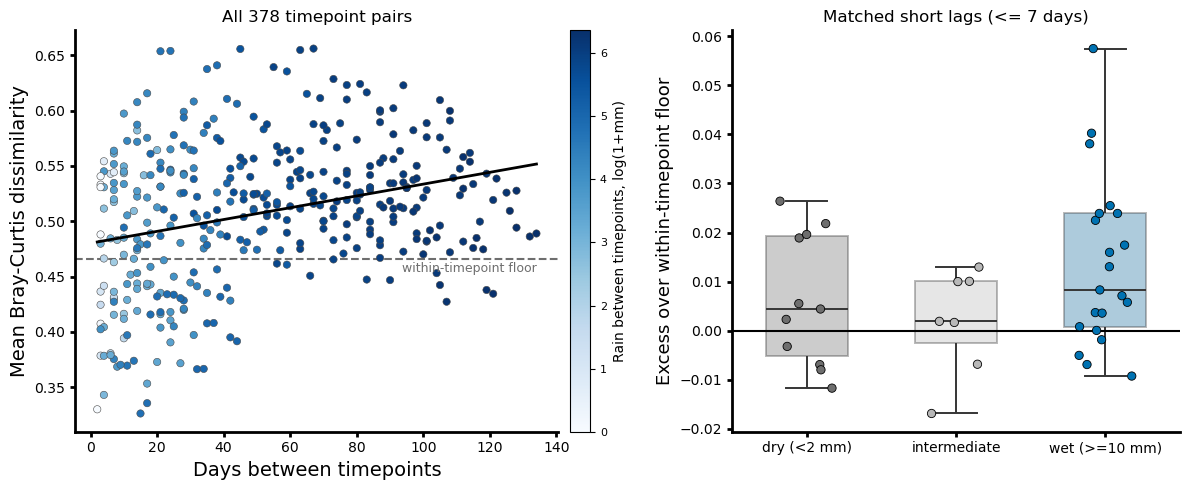

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), width_ratios=[1.3, 1])
fig.patch.set_facecolor("white")

ax = axes[0]
scatter = ax.scatter(
    timepoint_pairs["days_apart"],
    timepoint_pairs["mean_bc"],
    c=np.log1p(timepoint_pairs["rain_between"]),
    cmap="Blues",
    s=28,
    edgecolor="#4a4a4a",
    linewidth=0.4,
)
fit_x = np.linspace(timepoint_pairs["days_apart"].min(), timepoint_pairs["days_apart"].max(), 100)
slope, intercept = np.polyfit(timepoint_pairs["days_apart"], timepoint_pairs["mean_bc"], 1)
ax.plot(fit_x, slope * fit_x + intercept, color="black", linewidth=2, zorder=3)
ax.axhline(all_within.mean(), color=COLOR_WITHIN, linestyle="dashed", linewidth=1.5, zorder=0)
ax.text(
    timepoint_pairs["days_apart"].max(),
    all_within.mean() - 0.012,
    "within-timepoint floor",
    fontsize=9,
    color=COLOR_WITHIN,
    ha="right",
)
colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
colorbar.set_label("Rain between timepoints, log(1+mm)", fontsize=10)
colorbar.ax.tick_params(labelsize=8)
ax.set_xlabel("Days between timepoints", fontsize=14)
ax.set_ylabel("Mean Bray-Curtis dissimilarity", fontsize=14)
ax.set_title(f"All {len(timepoint_pairs)} timepoint pairs", fontsize=12)
style_axes(ax)

ax = axes[1]
classes = ["dry (<2 mm)", "intermediate", "wet (>=10 mm)"]
class_colors = {"dry (<2 mm)": COLOR_WITHIN, "intermediate": "#B8B8B8", "wet (>=10 mm)": COLOR_PRE_POST}
sns.boxplot(
    data=short_lag,
    x="rain_class",
    y="excess_bc",
    order=classes,
    hue="rain_class",
    palette=class_colors,
    legend=False,
    fliersize=0,
    width=0.55,
    linewidth=1.4,
    boxprops={"alpha": 0.35},
    ax=ax,
)
sns.stripplot(
    data=short_lag,
    x="rain_class",
    y="excess_bc",
    order=classes,
    hue="rain_class",
    palette=class_colors,
    legend=False,
    size=6,
    jitter=0.18,
    edgecolor="black",
    linewidth=0.6,
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1.5)
ax.set_xlabel("")
ax.set_ylabel("Excess over within-timepoint floor", fontsize=13)
ax.set_title("Matched short lags (<= 7 days)", fontsize=12)
ax.tick_params(axis="x", labelsize=9)
style_axes(ax)

plt.tight_layout()

Across the full six months, compositional turnover grows with elapsed time (partial Spearman 0.61)
and rainfall adds a small independent effect (partial Spearman 0.16, p = 0.002). But time and rain
are badly collinear here — long gaps are wet gaps — and once you restrict to pairs a week or less
apart, where genuinely dry and genuinely wet intervals both exist, the rain signal vanishes
completely (0.007 vs 0.007 excess, Mann-Whitney p = 0.96). The apparent rain effect in the full
model is carried by long-lag pairs, i.e. by season.

## 7. Where the events sit in ordination space

PCoA on the same genus-level Bray-Curtis matrix, so the ordination and the distances are the same
metric. Each panel highlights one event's `pre -> post -> recovered` centroid trajectory against all
28 timepoint centroids. A community that reassembles sends the second arrow back toward where the
first one started.

(Luke's own seasonal ordination is available at `Microbiome/AT_16S_ord_seas.csv` for the same 222
samples, as an external cross-check.)

In [14]:
genus_distance_matrix = DistanceMatrix(genus_bc.values, ids=list(genus_bc.index))
ordination = pcoa(genus_distance_matrix, number_of_dimensions=3)
pcoa_coords = ordination.samples.iloc[:, :2].copy()
pcoa_coords.columns = ["PC1", "PC2"]
pcoa_coords.index = genus_bc.index
timepoint_centroids = pcoa_coords.groupby(timepoint_of_sample).mean()

variance_explained = ordination.proportion_explained
print(
    "PCoA variance explained: "
    f"PC1 {variance_explained.iloc[0]:.1%}, PC2 {variance_explained.iloc[1]:.1%}"
)

centroid_travel = pd.DataFrame(
    [
        {
            "event": ev["name"],
            "pre -> post": np.linalg.norm(
                timepoint_centroids.loc[ev["post"]] - timepoint_centroids.loc[ev["pre"]]
            ),
            "pre -> recovered": np.linalg.norm(
                timepoint_centroids.loc[ev["recovered"]] - timepoint_centroids.loc[ev["pre"]]
            ),
        }
        for ev in EVENTS
    ]
).set_index("event")
centroid_travel["returned toward pre"] = (
    centroid_travel["pre -> recovered"] < centroid_travel["pre -> post"]
)
centroid_travel.round(3)

PCoA variance explained: PC1 22.9%, PC2 13.8%


,pre -> post,pre -> recovered,returned toward pre
event,,,
Nov 21-28,0.041,0.105,False
Dec 1-5,0.123,0.107,True
Dec 8-12,0.115,0.216,False
Jan 5-15,0.030,0.081,False
Mar 5-8,0.076,0.066,True


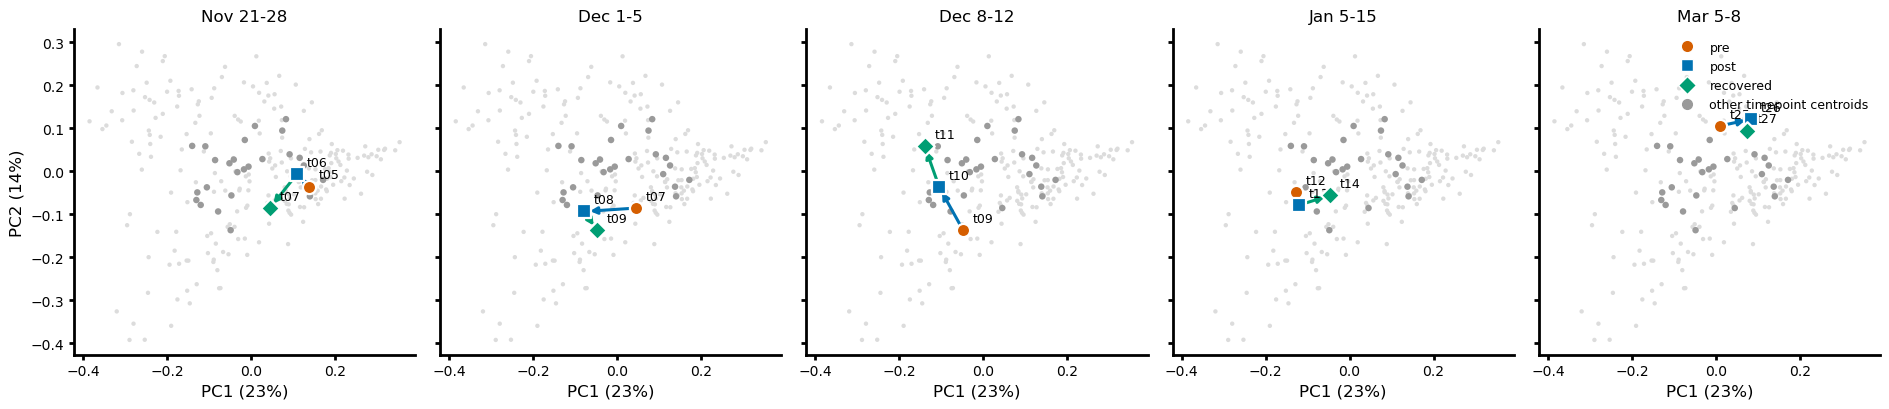

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(19, 4.2), sharex=True, sharey=True)
fig.patch.set_facecolor("white")

for ax, ev in zip(axes, EVENTS):
    ax.scatter(
        pcoa_coords["PC1"],
        pcoa_coords["PC2"],
        s=10,
        color="#DCDCDC",
        edgecolor="none",
        zorder=0,
    )
    ax.scatter(
        timepoint_centroids["PC1"],
        timepoint_centroids["PC2"],
        s=22,
        color="#9A9A9A",
        edgecolor="none",
        zorder=1,
    )
    path = timepoint_centroids.loc[[ev["pre"], ev["post"], ev["recovered"]]]
    for (x0, y0), (x1, y1), color in zip(
        path.values[:-1], path.values[1:], [COLOR_PRE_POST, COLOR_POST_REC]
    ):
        ax.annotate(
            "",
            xy=(x1, y1),
            xytext=(x0, y0),
            arrowprops={"arrowstyle": "-|>", "color": color, "linewidth": 2.2, "shrinkA": 4, "shrinkB": 4},
            zorder=3,
        )
    for (label, marker, color) in [
        (ev["pre"], "o", COLOR_PRE_REC),
        (ev["post"], "s", COLOR_PRE_POST),
        (ev["recovered"], "D", COLOR_POST_REC),
    ]:
        point = timepoint_centroids.loc[label]
        ax.scatter(
            point["PC1"], point["PC2"], s=90, marker=marker, color=color,
            edgecolor="white", linewidth=1.6, zorder=4,
        )
        ax.annotate(label, (point["PC1"], point["PC2"]), textcoords="offset points",
                    xytext=(7, 6), fontsize=9)
    ax.set_title(ev["name"], fontsize=12)
    ax.set_xlabel(f"PC1 ({variance_explained.iloc[0]:.0%})", fontsize=12)
    style_axes(ax)

axes[0].set_ylabel(f"PC2 ({variance_explained.iloc[1]:.0%})", fontsize=12)
legend_handles = [
    plt.Line2D([], [], marker="o", linestyle="none", color=COLOR_PRE_REC, markersize=9, markeredgecolor="white", label="pre"),
    plt.Line2D([], [], marker="s", linestyle="none", color=COLOR_PRE_POST, markersize=9, markeredgecolor="white", label="post"),
    plt.Line2D([], [], marker="D", linestyle="none", color=COLOR_POST_REC, markersize=9, markeredgecolor="white", label="recovered"),
    plt.Line2D([], [], marker="o", linestyle="none", color="#9A9A9A", markersize=7, label="other timepoint centroids"),
]
axes[-1].legend(handles=legend_handles, fontsize=9, frameon=False, loc="upper right")
plt.tight_layout()

The trajectories do not close. In three of five events the recovered centroid is *further* from the
pre-rain centroid than the disturbed one was, and where it is closer (Dec 1-5, Mar 5-8) it is only
marginally so, with the second arrow continuing in roughly the same direction rather than doubling
back. Note also how small every event trajectory is next to the spread of the grey background
points.

## 8. Statistics

Pairwise distances are not independent, so ordinary t-tests are invalid. Three permutation-based
tests instead:

- **PERMANOVA** — is there any compositional difference among `pre`/`post`/`recovered`?
- **PERMDISP** — if there is, is it really a *dispersion* change rather than a location shift?
  Worth checking here, since within-timepoint spread visibly changes across rain (t12 = 0.571,
  t13 = 0.432).
- **A label-shuffling test** on the headline contrast, `mean BC(pre, recovered) - mean BC(pre, post)`.

All p-values are Benjamini-Hochberg corrected across the five events.

In [16]:
def permutation_contrast(bc, pre, post, recovered, n_permutations=9999, seed=0):
    """Permute timepoint labels within an event and recompute BC(pre,rec) - BC(pre,post)."""
    rng = np.random.default_rng(seed)
    samples = list(samples_at[pre]) + list(samples_at[post]) + list(samples_at[recovered])
    labels = np.array(
        [pre] * len(samples_at[pre])
        + [post] * len(samples_at[post])
        + [recovered] * len(samples_at[recovered])
    )
    submatrix = bc.loc[samples, samples].values

    def statistic(assignment):
        group_mean = lambda x, y: submatrix[np.ix_(assignment == x, assignment == y)].mean()
        return group_mean(pre, recovered) - group_mean(pre, post)

    observed = statistic(labels)
    null = np.array([statistic(rng.permutation(labels)) for _ in range(n_permutations)])
    p_value = (np.sum(np.abs(null) >= abs(observed)) + 1) / (n_permutations + 1)
    return observed, p_value


def run_event_statistics(bc):
    rows = []
    for ev in EVENTS:
        pre, post, rec = ev["pre"], ev["post"], ev["recovered"]
        samples = list(samples_at[pre]) + list(samples_at[post]) + list(samples_at[rec])
        grouping = (
            ["pre"] * len(samples_at[pre])
            + ["post"] * len(samples_at[post])
            + ["recovered"] * len(samples_at[rec])
        )
        dm = DistanceMatrix(bc.loc[samples, samples].values, ids=samples)
        anova_result = permanova(dm, grouping, permutations=999)
        disp_result = permdisp(dm, grouping, permutations=999)
        delta, delta_p = permutation_contrast(bc, pre, post, rec)
        rows.append(
            {
                "event": ev["name"],
                "pseudo-F": anova_result["test statistic"],
                "PERMANOVA p": anova_result["p-value"],
                "PERMDISP p": disp_result["p-value"],
                "delta (pre-rec minus pre-post)": delta,
                "delta p": delta_p,
            }
        )
    table = pd.DataFrame(rows).set_index("event")
    table["PERMANOVA q"] = multipletests(table["PERMANOVA p"], method="fdr_bh")[1]
    table["delta q"] = multipletests(table["delta p"], method="fdr_bh")[1]
    return table


genus_statistics = run_event_statistics(genus_bc)
genus_statistics.round(4)

,pseudo-F,PERMANOVA p,PERMDISP p,delta (pre-rec minus pre-post),delta p,PERMANOVA q,delta q
event,,,,,,,
Nov 21-28,1.5634,0.026,0.597,0.0456,0.3031,0.1300,0.4876
Dec 1-5,1.5086,0.057,0.675,0.0305,0.3258,0.1425,0.4876
Dec 8-12,1.2919,0.181,0.747,0.0186,0.5450,0.3017,0.5450
Jan 5-15,0.8620,0.646,0.122,0.0667,0.1168,0.6460,0.4876
Mar 5-8,0.9936,0.383,0.445,-0.0269,0.3901,0.4788,0.4876


## 9. Species-level sensitivity check

Everything above is at genus level, matching the rest of the project. Species level is finer and
should be more sensitive to reassembly, so it is worth confirming the direction does not flip.

In [17]:
species_event_summary = event_summary(species_bc)
comparison = pd.DataFrame(
    {
        "genus": genus_event_summary[
            ["excess pre-post", "excess post-recovered", "excess pre-recovered"]
        ].mean(),
        "species": species_event_summary[
            ["excess pre-post", "excess post-recovered", "excess pre-recovered"]
        ].mean(),
    }
)
print("Pooled excess over the within-timepoint floor:")
print(comparison.round(4).to_string())
print()
species_event_summary.round(3)

Pooled excess over the within-timepoint floor:
                        genus  species
excess pre-post        0.0029   0.0009
excess post-recovered  0.0016   0.0068
excess pre-recovered   0.0211   0.0156



,within pre,within post,within recovered,pre vs post,post vs recovered,pre vs recovered,excess pre-post,excess post-recovered,excess pre-recovered
event,,,,,,,,,
Nov 21-28,0.663,0.576,0.653,0.631,0.625,0.684,0.012,0.010,0.026
Dec 1-5,0.653,0.544,0.580,0.606,0.601,0.639,0.008,0.040,0.023
Dec 8-12,0.580,0.624,0.637,0.605,0.621,0.634,0.003,-0.009,0.026
Jan 5-15,0.656,0.507,0.632,0.567,0.564,0.637,-0.014,-0.006,-0.007
Mar 5-8,0.445,0.514,0.438,0.475,0.475,0.452,-0.004,-0.001,0.011


In [18]:
species_statistics = run_event_statistics(species_bc)
species_statistics.round(4)

,pseudo-F,PERMANOVA p,PERMDISP p,delta (pre-rec minus pre-post),delta p,PERMANOVA q,delta q
event,,,,,,,
Nov 21-28,1.4513,0.042,0.367,0.0524,0.1951,0.1050,0.421
Dec 1-5,1.6115,0.029,0.207,0.0332,0.2669,0.1050,0.421
Dec 8-12,1.1925,0.220,0.603,0.0293,0.3368,0.3667,0.421
Jan 5-15,0.7571,0.839,0.067,0.0694,0.0710,0.8390,0.355
Mar 5-8,1.0913,0.365,0.597,-0.0230,0.4750,0.4562,0.475


## 10. Conclusion

**The communities that reassemble after rain are not the communities that were there before it.**

Four results, all pointing the same way:

1. **Rain-driven turnover is small next to plant-to-plant variation.** Two plants harvested the same
   morning differ by Bray-Curtis ~0.47; two plants separated by a rain event differ by ~0.50. The
   excess attributable to crossing a rain event is ~0.003 — under 1% of the distance scale.

2. **`pre vs recovered` is the *largest* distance, not the smallest.** Pooled excess over the
   within-timepoint floor is 0.021 for `pre vs recovered` against 0.003 for `pre vs post`. If the
   community were snapping back, this ordering would be reversed. Instead it is exactly the pattern
   produced by steady directional drift, where anything further apart in time is further apart in
   composition.

3. **No event survives correction.** Two of five events reach nominal PERMANOVA p < 0.05 but none
   survives Benjamini-Hochberg (all q > 0.12), PERMDISP is null throughout (so the nominal hits are
   not dispersion artefacts either), and the label-shuffling test on the headline contrast is null
   for every event (all q ~ 0.50).

4. **The apparent rain effect over the whole season is really time.** Rainfall predicts turnover in
   the all-pairs model (partial Spearman 0.16 given days apart, p = 0.002), but that is carried
   entirely by long-lag pairs where wet and long are the same thing. At lags of a week or less,
   where wet and dry intervals are directly comparable, wet and dry pairs have identical excess
   distance (0.007 vs 0.007, p = 0.96).

Genus and species level agree in direction, so this is not an artefact of taxonomic resolution.

### What this means for the Shannon result

The Shannon recovery in the source notebook is real, but it is a recovery of **evenness, not of
membership**. Diversity refills; the specific community that refills it keeps moving. Rain looks
less like a disturbance the community bounces back from and more like one more input to a phyllosphere
that is drifting continuously through the season anyway.

### Honest limits

- **Power.** Eight plants per timepoint against a within-timepoint dissimilarity of ~0.47 gives very
  little power to detect a shift of a few hundredths. This is bounded evidence that rain effects are
  *small relative to plant heterogeneity*, not proof they are zero.
- **The source table is filtered to taxa at >= 0.5% relative abundance**, so this analysis sees only
  dominant members. Reassembly among rare taxa would be invisible here.
- **Destructive harvest** means no plant is followed through an event; every comparison is between
  different individuals, which is why the within-timepoint floor is the correct reference and why it
  is so high.
- **Sampling cadence (3-7 days) may be too coarse.** If reassembly happens within a day or two, the
  `post` sample already contains a partly recovered community and the contrast is blunted. The
  circadian sampling series would be the place to look for a faster signal.